# EDA

Identifying high level patterns, substructures, missing elements, and flaws in the datasets 

## Loading datasets

In [1]:
# Convert raw csv files into pandas dataframes

import pandas as pd

ALE_RAW = "../data/raw/account_lifecycle_events.csv"
UEM_RAW = "../data/raw/user_engagement_metrics.csv"
SIH_RAW = "../data/raw/support_interaction_history.csv"

ale_df = pd.read_csv(ALE_RAW, parse_dates=['created_timestamp', 'last_activity_timestamp', 'status_change_date', 'contract_end_date'])
uem_df = pd.read_csv(UEM_RAW, parse_dates=['user_created_date', 'last_login_date'])
sih_df = pd.read_csv(SIH_RAW, parse_dates=['created_date', 'resolved_date'])

# pandas treats the string 'NA' as null by default — restore North America region
ale_df['region'] = ale_df['region'].fillna('NA')


In [2]:
# Generate sweetviz profiles on the three datasets for quick references 

# import sweetviz as sv
# import os

# ale_report = sv.analyze(ale_df)
# uem_report = sv.analyze(uem_df)
# sih_report = sv.analyze(sih_df)

# ale_report.show_html("../data/profiles/ale_report.html", open_browser=False)
# uem_report.show_html("../data/profiles/uem_report.html", open_browser=False)
# sih_report.show_html("../data/profiles/sih_report.html", open_browser=False)

## Preprocessing

**Timestamps --> Durations**

### Converting timestamps to durations

Confirm all date columns parse to the same dtype across the three datasets before computing durations.

Timestamp columns are converted to integer day offsets relative to a `SNAPSHOT_DATE` anchored to the latest record across the three CSV files. This is the next best alternative to an actual extraction date.

**Sign convention:** `(snapshot_date - col).dt.days`  
- Positive → event is in the past (e.g. account created 400 days ago)  
- Negative → event is in the future (e.g. `days_since_contract_end = -30` means contract ends in 30 days)

In [3]:
# Verify dtype and sample values for every timestamp column across all three datasets

timestamp_cols = {
    'ALE': ['created_timestamp', 'last_activity_timestamp', 'status_change_date', 'contract_end_date'],
    'UEM': ['user_created_date', 'last_login_date'],
    'SIH': ['created_date', 'resolved_date'],
}
frames = {'ALE': ale_df, 'UEM': uem_df, 'SIH': sih_df}

for table, cols in timestamp_cols.items():
    df = frames[table]
    for col in cols:
        sample = df[col].dropna().iloc[0] if df[col].notna().any() else None
        print(f"{table}.{col:35s}  dtype={str(df[col].dtype):20s}  sample={sample}")
    print()

ALE.created_timestamp                    dtype=datetime64[us]        sample=2022-08-17 00:00:00
ALE.last_activity_timestamp              dtype=datetime64[us]        sample=2024-12-21 00:00:00
ALE.status_change_date                   dtype=datetime64[us]        sample=2023-12-17 00:00:00
ALE.contract_end_date                    dtype=datetime64[us]        sample=2024-08-16 00:00:00

UEM.user_created_date                    dtype=datetime64[us]        sample=2022-09-01 00:00:00
UEM.last_login_date                      dtype=datetime64[us]        sample=2024-12-18 00:00:00

SIH.created_date                         dtype=datetime64[us]        sample=2023-02-12 00:00:00
SIH.resolved_date                        dtype=datetime64[us]        sample=2023-02-13 02:03:45.742785



In [4]:
# Create metadata df for timeframe columns based on operational use case
# TODO status_change_date could be a leakage risk since some are scheduled for the future

timestamp_metadata = pd.DataFrame([
    {'field': 'created_timestamp',       'csv_file': 'ale', 'forward_looking': False, 'use_for_snapshot': True},   # within cluster
    {'field': 'last_activity_timestamp', 'csv_file': 'ale', 'forward_looking': False, 'use_for_snapshot': True},   # within cluster
    {'field': 'status_change_date',      'csv_file': 'ale', 'forward_looking': True,  'use_for_snapshot': False},  # can record future scheduled changes, leakage risk
    {'field': 'contract_end_date',       'csv_file': 'ale', 'forward_looking': True,  'use_for_snapshot': False},  # no leakage risk, expect negative durations at times
    {'field': 'user_created_date',       'csv_file': 'uem', 'forward_looking': False, 'use_for_snapshot': False},  # creation dates lag activity cutoff so best not to include in snapshot
    {'field': 'last_login_date',         'csv_file': 'uem', 'forward_looking': False, 'use_for_snapshot': True},   # within cluster
    {'field': 'created_date',            'csv_file': 'sih', 'forward_looking': False, 'use_for_snapshot': True},   # within cluster
    {'field': 'resolved_date',           'csv_file': 'sih', 'forward_looking': False, 'use_for_snapshot': True},   # within cluster
]).set_index('field')
display(timestamp_metadata)

,csv_file,forward_looking,use_for_snapshot
field,,,
created_timestamp,ale,False,True
last_activity_timestamp,ale,False,True
status_change_date,ale,True,False
contract_end_date,ale,True,False
user_created_date,uem,False,False
last_login_date,uem,False,True
created_date,sih,False,True
resolved_date,sih,False,True


In [5]:
# Calculating snapshot date based on 

snapshot_cols = timestamp_metadata[timestamp_metadata['use_for_snapshot']]

SNAPSHOT_DATE = pd.concat([
    ale_df[snapshot_cols[snapshot_cols['csv_file'] == 'ale'].index],
    uem_df[snapshot_cols[snapshot_cols['csv_file'] == 'uem'].index],
    sih_df[snapshot_cols[snapshot_cols['csv_file'] == 'sih'].index]
]).max().max().normalize()

print(f"Snapshot date: {SNAPSHOT_DATE.date()}")

Snapshot date: 2025-01-02


In [6]:
# Observing the min and max range for timestamps to confirm usage in snapshot calculations

max_rows = []
for field, row in timestamp_metadata.iterrows():
    df = frames[row['csv_file'].upper()]
    max_rows.append({
        'field': field,
        'csv_file': row['csv_file'],
        'forward_looking': row['forward_looking'],
        'use_for_snapshot': row['use_for_snapshot'],
        'min_value': df[field].min(),
        'max_value': df[field].max()
    })

max_df = pd.DataFrame(max_rows).set_index('field')
display(max_df)

,csv_file,forward_looking,use_for_snapshot,min_value,max_value
field,,,,,
created_timestamp,ale,False,True,2022-01-01 00:00:00.000000,2024-12-31 00:00:00.000000
last_activity_timestamp,ale,False,True,2024-09-18 00:00:00.000000,2024-12-31 00:00:00.000000
status_change_date,ale,True,False,2022-02-21 00:00:00.000000,2026-04-21 00:00:00.000000
contract_end_date,ale,True,False,2023-01-01 00:00:00.000000,2026-12-31 00:00:00.000000
user_created_date,uem,False,False,2022-01-02 00:00:00.000000,2025-03-30 00:00:00.000000
last_login_date,uem,False,True,2024-07-04 00:00:00.000000,2024-12-31 00:00:00.000000
created_date,sih,False,True,2022-01-04 00:00:00.000000,2025-01-01 00:00:00.000000
resolved_date,sih,False,True,2022-01-05 13:43:15.337997,2025-01-02 20:28:49.046460


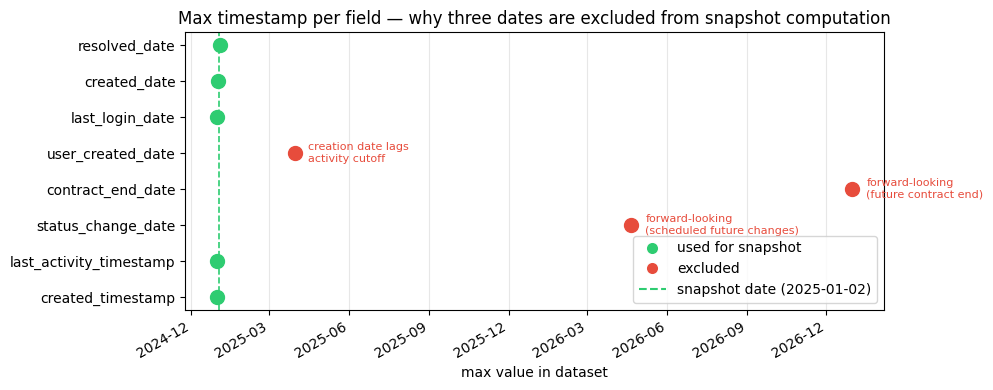

In [7]:
# Plotting max timestamp to visually confirm outliers

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

CLUSTER_DATE = pd.Timestamp("2025-01-02")
exclusion_reasons = {
    'status_change_date': 'forward-looking\n(scheduled future changes)',
    'contract_end_date':  'forward-looking\n(future contract end)',
    'user_created_date':  'creation date lags\nactivity cutoff',
}

fig, ax = plt.subplots(figsize=(10, 4))

for i, (field, row) in enumerate(max_df.iterrows()):
    color = '#2ecc71' if row['use_for_snapshot'] else '#e74c3c'
    ax.scatter(row['max_value'], i, color=color, s=100, zorder=3)
    if field in exclusion_reasons:
        ax.annotate(
            exclusion_reasons[field],
            xy=(row['max_value'], i),
            xytext=(10, 0), textcoords='offset points',
            va='center', fontsize=8, color='#e74c3c',
        )

ax.axvline(CLUSTER_DATE, color='#2ecc71', linestyle='--', linewidth=1.2, label=f'snapshot date ({CLUSTER_DATE.date()})')

ax.set_yticks(range(len(max_df)))
ax.set_yticklabels(max_df.index)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30, ha='right')
ax.set_xlabel('max value in dataset')
ax.set_title('Max timestamp per field — why three dates are excluded from snapshot computation')

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=9, label='used for snapshot'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=9, label='excluded'),
    Line2D([0], [0], color='#2ecc71', linestyle='--', label=f'snapshot date ({CLUSTER_DATE.date()})'),
]
ax.legend(handles=legend_handles, loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

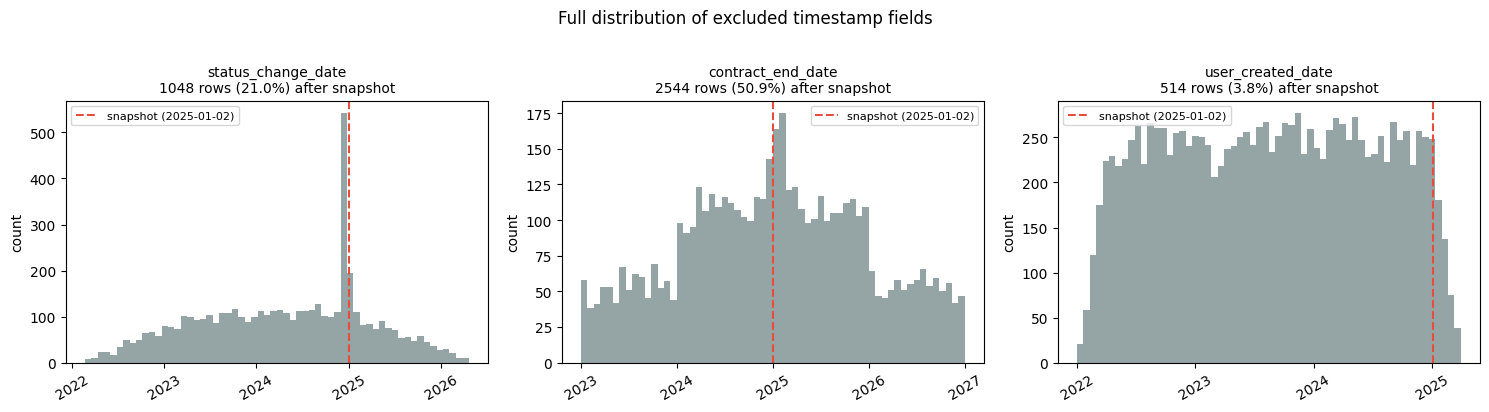

In [8]:
# Plotting distribution of excluded fields to show future events
# TODO the plot for status_change_date is anomalistic, lots of changes around snapshot date

excluded_meta = timestamp_metadata[timestamp_metadata['use_for_snapshot'] == False]

excluded_fields = {
    field: frames[row['csv_file'].upper()][field]
    for field, row in excluded_meta.iterrows()
}

fig, axes = plt.subplots(1, len(excluded_fields), figsize=(15, 4), sharey=False)

for ax, (field, series) in zip(axes, excluded_fields.items()):
    non_null = series.dropna()
    ax.hist(non_null, bins=60, color='#95a5a6', edgecolor='none')
    ax.axvline(SNAPSHOT_DATE, color='#e74c3c', linestyle='--', linewidth=1.5, label=f'snapshot ({SNAPSHOT_DATE.date()})')
    future_count = (non_null > SNAPSHOT_DATE).sum()
    future_pct = future_count / len(non_null) * 100
    ax.set_title(f'{field}\n{future_count} rows ({future_pct:.1f}%) after snapshot', fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)
    ax.set_ylabel('count')

plt.suptitle('Full distribution of excluded timestamp fields', y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# Function to convert timestamps in data to durations (in days), mutating the df in-place

def timestamps_to_durations(df, column_map, reference_date):
    """
    Add signed integer day-offset columns to df in-place and drop the source timestamp columns.

    column_map: {src_col: dst_col}  e.g. {'created_timestamp': 'days_since_creation'}
    reference_date: pd.Timestamp — the "as-of" date; use SNAPSHOT_DATE, not today.
    """
    for src_col, dst_col in column_map.items():
        df[dst_col] = (reference_date - df[src_col]).dt.days

In [10]:
ale_column_map = {
    'created_timestamp':       'days_since_creation',
    'last_activity_timestamp': 'days_since_last_activity',
    'contract_end_date':       'days_since_contract_end',   # negative = contract hasn't ended yet
    'status_change_date':      'days_since_status_change',  # spike near snapshot — see next cell
}

uem_column_map = {
    'last_login_date':   'days_since_last_login',
    'user_created_date': 'days_since_user_creation',
}

sih_column_map = {
    'created_date':  'days_since_ticket_creation',
    'resolved_date': 'days_since_resolution',
}

timestamps_to_durations(ale_df, ale_column_map, SNAPSHOT_DATE)
timestamps_to_durations(uem_df, uem_column_map, SNAPSHOT_DATE)
timestamps_to_durations(sih_df, sih_column_map, SNAPSHOT_DATE)

display(ale_df[list(ale_column_map.values())].head(3))
display(uem_df[list(uem_column_map.values())].head(3))
display(sih_df[list(sih_column_map.values())].head(3))

,days_since_creation,days_since_last_activity,days_since_contract_end,days_since_status_change
0,869,12,139,382
1,1046,11,316,731
2,534,23,169,157


,days_since_last_login,days_since_user_creation
0,15,854
1,6,856
2,11,797


,days_since_ticket_creation,days_since_resolution
0,690,688
1,342,340
2,394,392


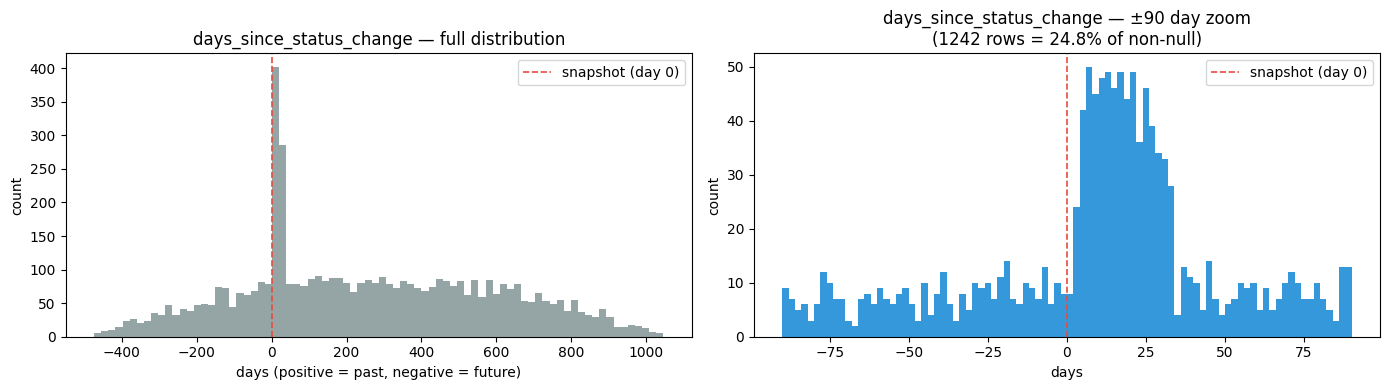

count    5000.000000
mean      253.638800
std       332.683659
min      -474.000000
25%        11.000000
50%       213.000000
75%       515.250000
max      1046.000000

Rows at exactly day 0 (status_change = snapshot date): 3
Rows within ±7 days of snapshot:                       155
Rows within ±30 days of snapshot:                      766


In [11]:
# Investigate days_since_status_change — cell-11 flagged an anomalistic spike near the snapshot date
# Hypothesis: many accounts have a status_change_date clustered just before/at the snapshot,
# which would make this column a near-constant near 0 for a large fraction of rows — weak signal.

col = 'days_since_status_change'
series = ale_df[col].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(series, bins=80, color='#95a5a6', edgecolor='none')
axes[0].axvline(0, color='#e74c3c', linestyle='--', linewidth=1.2, label='snapshot (day 0)')
axes[0].set_title(f'{col} — full distribution')
axes[0].set_xlabel('days (positive = past, negative = future)')
axes[0].set_ylabel('count')
axes[0].legend()

window = series[(series >= -90) & (series <= 90)]
axes[1].hist(window, bins=90, color='#3498db', edgecolor='none')
axes[1].axvline(0, color='#e74c3c', linestyle='--', linewidth=1.2, label='snapshot (day 0)')
axes[1].set_title(f'{col} — ±90 day zoom\n({len(window)} rows = {len(window)/len(series)*100:.1f}% of non-null)')
axes[1].set_xlabel('days')
axes[1].set_ylabel('count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(series.describe().to_string())
print(f"\nRows at exactly day 0 (status_change = snapshot date): {(series == 0).sum()}")
print(f"Rows within ±7 days of snapshot:                       {((series >= -7) & (series <= 7)).sum()}")
print(f"Rows within ±30 days of snapshot:                      {((series >= -30) & (series <= 30)).sum()}")

### Dropping obvious non-features

Candidate list:

**ALE**
- `account_uuid` --> signal already encoded by region and days_since_creation

**UEM**
- `account_uuid` --> redundant (ale)
- `user_email` --> redundant (1-1 with user_id)

**SIH**
- `account_uuid` --> redundant (ale)
- `org_id` --> redundant (ale)
- `retention_offer_accepted` (>99% false, <1% true) --> (no variance)
- `csat_score` --> deprecated, duplicate of satisfaction_score

In [12]:
# Test whether ale.account_uuid rows are redundant and encoded in other columns

has_uuid = ale_df["account_uuid"].notna()

is_eu        = ale_df["region"] == "EU"
is_post_2023 = ale_df["created_timestamp"] >= pd.Timestamp("2023-01-01")

both_conditions = is_eu & is_post_2023

total_with_uuid     = has_uuid.sum()
match_both          = (has_uuid & both_conditions).sum()
eu_only             = (has_uuid & is_eu & ~is_post_2023).sum()
post_2023_only      = (has_uuid & ~is_eu & is_post_2023).sum()
neither             = (has_uuid & ~is_eu & ~is_post_2023).sum()

print(f"Rows with non-null account_uuid:              {total_with_uuid}")
print(f"  match EU + created >= 2023:                 {match_both}  ({match_both/total_with_uuid*100:.1f}%)")
print(f"  EU only (created before 2023):              {eu_only}  ({eu_only/total_with_uuid*100:.1f}%)")
print(f"  created >= 2023 only (non-EU):              {post_2023_only}  ({post_2023_only/total_with_uuid*100:.1f}%)")
print(f"  neither condition (unexpected):             {neither}  ({neither/total_with_uuid*100:.1f}%)")

Rows with non-null account_uuid:              1071
  match EU + created >= 2023:                 1071  (100.0%)
  EU only (created before 2023):              0  (0.0%)
  created >= 2023 only (non-EU):              0  (0.0%)
  neither condition (unexpected):             0  (0.0%)


In [13]:
# Making drops

ALE_OBVIOUS_DROPS = ['account_uuid', 'data_residency_region']
UEM_OBVIOUS_DROPS = ['account_uuid', 'user_email']
SIH_OBVIOUS_DROPS = ['account_uuid', 'org_id', 'retention_offer_accepted', 'csat_score']

ale_df.drop(columns=ALE_OBVIOUS_DROPS, inplace=True)
uem_df.drop(columns=UEM_OBVIOUS_DROPS, inplace=True)
sih_df.drop(columns=SIH_OBVIOUS_DROPS, inplace=True)

### Investigating the grace period backfill gap

The data dictionary says that `grace_period` was introduced in v2.1 but not all historical data was backfilled. This means some accounts may show `active` when they should show `grace_period`.

**Why this matters for the model:**  
Some "active" accounts are technically pre-churn, which means they are closer to the positive class than the negative. This would reduce model recall because we would be supressing important signals that a customer is about to churn

In [14]:
# Count suspect actives by applying a proxy signature to the active cohort
# Proxy: annual contract has ended (days_since_contract_end > 0), any contract has ended, and auto_renew_enabled == False

active_df = ale_df[ale_df['account_status'] == 'active'].copy()

contract_lapsed = active_df['days_since_contract_end'] > 0
annual_contract_lapsed = contract_lapsed & (active_df['billing_cycle'] == 'annual')
no_auto_renew = active_df['auto_renew_enabled'] == False

# Hard: annual contract lapsed + no auto-renew (strongest signal — annual expiry is unambiguous)
suspect_hard = active_df[annual_contract_lapsed & no_auto_renew]

# Medium: any billing cycle lapsed + no auto-renew
suspect_medium = active_df[contract_lapsed & no_auto_renew]

# Easy: any lapsed contract regardless of auto-renew setting (loosest — includes renewal lag noise)
suspect_easy = active_df[contract_lapsed]

print(f"Active accounts total: {len(active_df)}")
print(f"\nSuspect active (hard: annual lapsed + no auto-renew):")
print(f"Count: {len(suspect_hard)}  ({len(suspect_hard)/len(active_df)*100:.1f}% of actives)")
print(f"\nSuspect active (medium: any lapsed + no auto-renew):")
print(f"Count: {len(suspect_medium)}  ({len(suspect_medium)/len(active_df)*100:.1f}% of actives)")
print(f"\nSuspect active (easy: any lapsed contract):")
print(f"Count: {len(suspect_easy)}  ({len(suspect_easy)/len(active_df)*100:.1f}% of actives)")

Active accounts total: 4454

Suspect active (hard: annual lapsed + no auto-renew):
Count: 193  (4.3% of actives)

Suspect active (medium: any lapsed + no auto-renew):
Count: 691  (15.5% of actives)

Suspect active (easy: any lapsed contract):
Count: 2202  (49.4% of actives)


In [15]:
# Materiality check — how much does the backfill gap shift the positive rate?

n_total   = len(ale_df)
n_churned = (ale_df['account_status'] == 'churned').sum()
n_grace   = (ale_df['account_status'] == 'grace_period').sum()

pos_baseline       = n_churned / n_total
pos_with_grace     = (n_churned + n_grace) / n_total  # n_grace=0, same as baseline
pos_hard_relabel   = (n_churned + len(suspect_hard))   / n_total
pos_medium_relabel = (n_churned + len(suspect_medium)) / n_total
pos_easy_relabel   = (n_churned + len(suspect_easy))   / n_total

print("Positive rate under each scenario:")
print(f"  A. Baseline (churned only):                         {pos_baseline*100:.1f}%")
print(f"  B. + hard suspects (annual lapsed, no auto-renew):  {pos_hard_relabel*100:.1f}%")
print(f"  C. + medium suspects (any lapsed, no auto-renew):   {pos_medium_relabel*100:.1f}%")
print(f"  D. + easy suspects (any lapsed — worst case):       {pos_easy_relabel*100:.1f}%")

delta_hard = (pos_hard_relabel - pos_baseline) * 100
delta_easy = (pos_easy_relabel - pos_baseline) * 100
print(f"\nShift from hard relabeling:  +{delta_hard:.1f} pp  (defensible lower bound)")
print(f"Shift from easy relabeling:  +{delta_easy:.1f} pp  (worst-case ceiling)")

print("\n--- Verdict ---")
if delta_hard < 2:
    print("Hard suspects are LOW materiality (<2pp). They can be flagged but won't move the model.")
    print("Focus contamination concern on the medium/easy cohorts if further investigation warrants.")
elif delta_hard < 5:
    print("Hard suspects are MODERATE materiality (2–5pp). Worth broadening the target to include them.")
else:
    print("Hard suspects alone are HIGH materiality (>5pp). Broaden the target or exclude them from training.")

Positive rate under each scenario:
  A. Baseline (churned only):                         10.9%
  B. + hard suspects (annual lapsed, no auto-renew):  14.8%
  C. + medium suspects (any lapsed, no auto-renew):   24.7%
  D. + easy suspects (any lapsed — worst case):       55.0%

Shift from hard relabeling:  +3.9 pp  (defensible lower bound)
Shift from easy relabeling:  +44.0 pp  (worst-case ceiling)

--- Verdict ---
Hard suspects are MODERATE materiality (2–5pp). Worth broadening the target to include them.


### Investigating the pre/post 2023 Q3 `account_health_score` algorithm

The `account_health_score` field uses a proprietary algorithm that **changed in Q3 2023**, and that "some data scientists have reported unexpected model behavior when using this feature."

Since we have no `score_calculated_date`, `created_timestamp` is the best available proxy  (accounts created 2023-10-01 were definitely scored under the new algorithm);

Investigation steps:
1. Confirm the bimodal shape and the dead-band in 40–60
2. Test correlation with `integration_count`
3. Test correlation with `subscription_tier`
4. KS test to measure difference between pre/post Q3 2023 distribution

In [16]:
# Define group split: end of Q3 2023 as the algorithm-change boundary
Q3_2023_END = pd.Timestamp("2023-10-01")

pre_mask  = ale_df['created_timestamp'] <  Q3_2023_END
post_mask = ale_df['created_timestamp'] >= Q3_2023_END

pre_scores  = ale_df.loc[pre_mask,  'account_health_score'].dropna()
post_scores = ale_df.loc[post_mask, 'account_health_score'].dropna()
all_scores  = ale_df['account_health_score'].dropna()

bins = range(0, 102, 2)

# Dead-band check (40-60 range)
dead_band_pct = ((all_scores > 40) & (all_scores < 60)).mean() * 100

print(f"Overall: n={len(all_scores):,}  mean={all_scores.mean():.1f}  std={all_scores.std():.1f}  "
      f"null={ale_df['account_health_score'].isna().sum()}")
print(f"Pre-Q3: n={len(pre_scores):,}  mean={pre_scores.mean():.1f}  std={pre_scores.std():.1f}")
print(f"Post-Q3: n={len(post_scores):,}  mean={post_scores.mean():.1f}  std={post_scores.std():.1f}")
print(f"\nScores in dead-band (40–60): {dead_band_pct:.1f}% of non-null rows")

Overall: n=5,000  mean=73.5  std=22.1  null=0
Pre-Q3: n=2,887  mean=73.7  std=22.2
Post-Q3: n=2,113  mean=73.3  std=21.9

Scores in dead-band (40–60): 0.0% of non-null rows


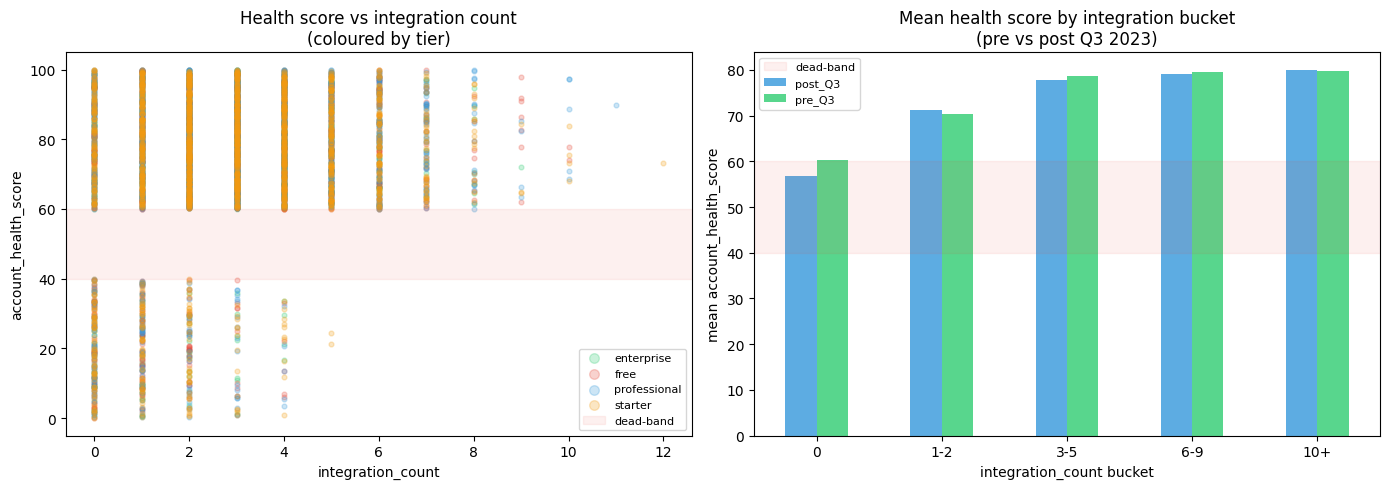

Pearson r(health_score, integration_count):  overall=0.253  pre=0.252  post=0.254


In [17]:
# Testing correlation with integration count

import numpy as np

score_int = ale_df[['account_health_score', 'integration_count', 'subscription_tier']].dropna()
score_int = score_int.assign(
    cohort=ale_df.loc[score_int.index, 'created_timestamp'].ge(Q3_2023_END).map({True: 'post_Q3', False: 'pre_Q3'})
)

tier_colors = {'free': '#e74c3c', 'starter': '#f39c12', 'professional': '#3498db', 'enterprise': '#2ecc71'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter coloured by tier
for tier, grp in score_int.groupby('subscription_tier'):
    axes[0].scatter(grp['integration_count'], grp['account_health_score'],
                    alpha=0.25, s=12, color=tier_colors.get(tier, '#95a5a6'), label=tier)
axes[0].axhspan(40, 60, color='#e74c3c', alpha=0.08, label='dead-band')
axes[0].set_xlabel('integration_count')
axes[0].set_ylabel('account_health_score')
axes[0].set_title('Health score vs integration count\n(coloured by tier)')
axes[0].legend(fontsize=8, markerscale=2)

# Right: mean health score per integration bucket × cohort
score_int['int_bucket'] = pd.cut(score_int['integration_count'], bins=[0,1,3,6,10,999],
                                  labels=['0', '1-2', '3-5', '6-9', '10+'], right=False)
bucket_means = (score_int.groupby(['int_bucket', 'cohort'], observed=True)['account_health_score']
                .mean().unstack('cohort'))

bucket_means.plot(kind='bar', ax=axes[1], color=['#3498db', '#2ecc71'], alpha=0.8, edgecolor='none')
axes[1].axhspan(40, 60, color='#e74c3c', alpha=0.08, label='dead-band')
axes[1].set_xlabel('integration_count bucket')
axes[1].set_ylabel('mean account_health_score')
axes[1].set_title('Mean health score by integration bucket\n(pre vs post Q3 2023)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Pearson correlation overall and per cohort
r_overall = score_int[['account_health_score', 'integration_count']].corr().iloc[0, 1]
r_pre  = score_int.loc[score_int['cohort'] == 'pre_Q3',  ['account_health_score', 'integration_count']].corr().iloc[0, 1]
r_post = score_int.loc[score_int['cohort'] == 'post_Q3', ['account_health_score', 'integration_count']].corr().iloc[0, 1]

print(f"Pearson r(health_score, integration_count):  overall={r_overall:.3f}  pre={r_pre:.3f}  post={r_post:.3f}")

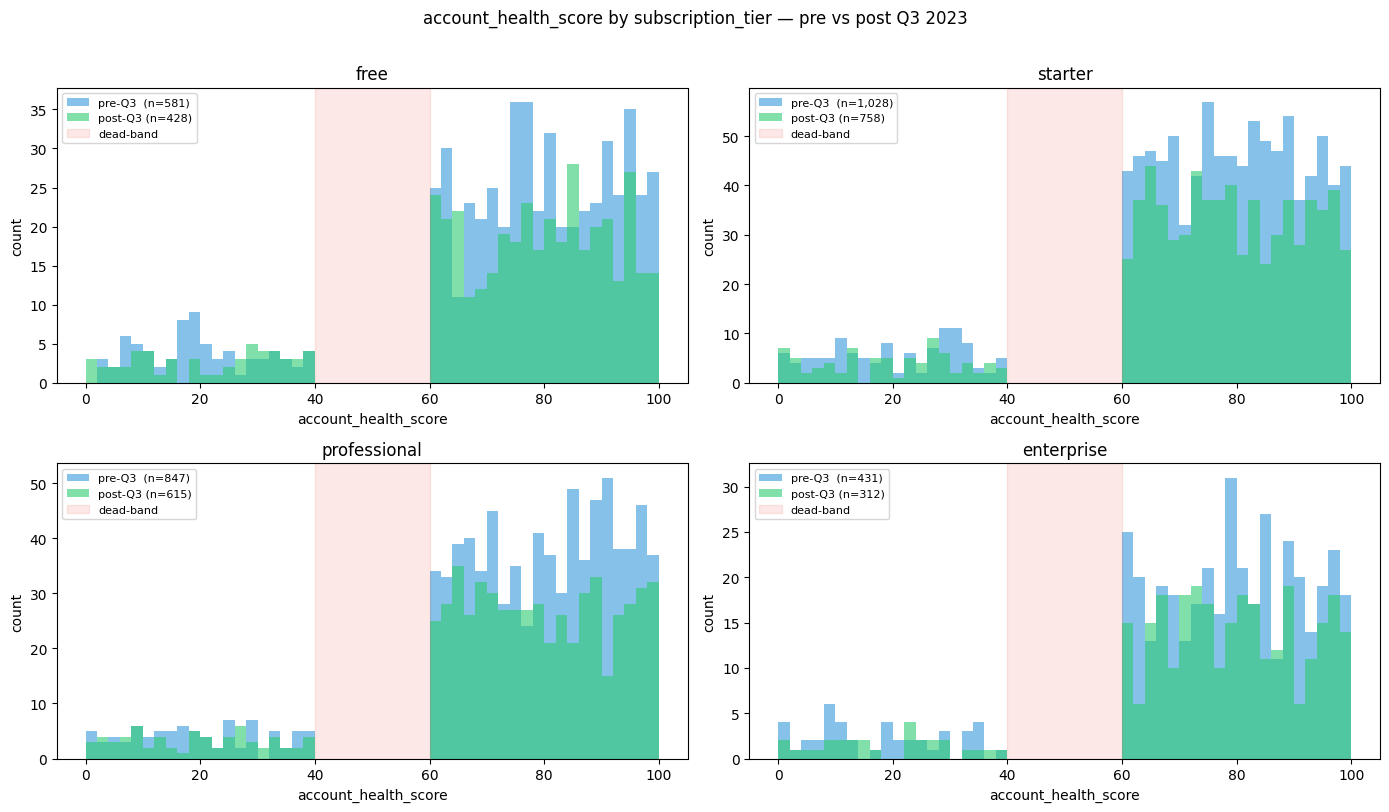

n   mean    std  pct_in_deadband
subscription_tier cohort                                      
enterprise        post_Q3   312  74.49  20.84              0.0
                  pre_Q3    431  73.80  22.11              0.0
free              post_Q3   428  72.59  22.51              0.0
                  pre_Q3    581  72.80  23.19              0.0
professional      post_Q3   615  73.23  22.20              0.0
                  pre_Q3    847  74.64  21.70              0.0
starter           post_Q3   758  73.40  21.78              0.0
                  pre_Q3   1028  73.38  21.97              0.0

In [18]:
# Testing distribution at each subscription tier since there was a 25% correlation

tiers = ['free', 'starter', 'professional', 'enterprise']
tier_order = {t: i for i, t in enumerate(tiers)}

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)
axes = axes.flatten()

for ax, tier in zip(axes, tiers):
    pre_tier  = ale_df.loc[pre_mask  & (ale_df['subscription_tier'] == tier), 'account_health_score'].dropna()
    post_tier = ale_df.loc[post_mask & (ale_df['subscription_tier'] == tier), 'account_health_score'].dropna()

    ax.hist(pre_tier,  bins=bins, color='#3498db', alpha=0.6, edgecolor='none', label=f'pre-Q3  (n={len(pre_tier):,})')
    ax.hist(post_tier, bins=bins, color='#2ecc71', alpha=0.6, edgecolor='none', label=f'post-Q3 (n={len(post_tier):,})')
    ax.axvspan(40, 60, color='#e74c3c', alpha=0.12, label='dead-band')

    ax.set_title(f'{tier}')
    ax.set_xlabel('account_health_score')
    ax.set_ylabel('count')
    ax.legend(fontsize=8)

plt.suptitle('account_health_score by subscription_tier — pre vs post Q3 2023', y=1.01)
plt.tight_layout()
plt.show()

summary = (
    ale_df.assign(cohort=ale_df['created_timestamp'].ge(Q3_2023_END).map({True: 'post_Q3', False: 'pre_Q3'}))
    .groupby(['subscription_tier', 'cohort'])['account_health_score']
    .agg(n='count', mean='mean', std='std', pct_in_deadband=lambda s: ((s > 40) & (s < 60)).mean() * 100)
    .round(2)
)
display(summary)

In [19]:
# KS test to measure whether pre/post Q3 2023 health score distributions are statistically different
from scipy.stats import ks_2samp

ks_stat, ks_p = ks_2samp(pre_scores, post_scores)

print(f"KS statistic: {ks_stat:.4f}")
print(f"p-value:      {ks_p:.4f}")
print()
if ks_p < 0.05:
    print("Result: SIGNIFICANT — pre/post distributions are statistically different (p < 0.05).")
    print("The algorithm change left a detectable distributional fingerprint.")
    print("Consider cohort-based treatment: interaction terms or separate models for pre/post.")
else:
    print("Result: NOT SIGNIFICANT — distributions are statistically indistinguishable (p >= 0.05).")
    print("The algorithm change left no detectable distributional fingerprint.")
    print("Cohort-based treatment (interaction terms, pre/post split) is not justified by the data.")

KS statistic: 0.0305
p-value:      0.2021

Result: NOT SIGNIFICANT — distributions are statistically indistinguishable (p >= 0.05).
The algorithm change left no detectable distributional fingerprint.
Cohort-based treatment (interaction terms, pre/post split) is not justified by the data.


### Investigating the mismatch between uem.user_id and sih.user_id

There is a "legacy sync issue" between these fields. However examining the data confirms UEM uses `USR` + 10 hex chars and SIH uses `USR` + 4 digits so the gap could be more structural than partial mismatches. 


Investigation steps:

1. **Match rate** — fraction of UEM `user_id`s that appear in SIH and vice versa.
2. **Regex format** — confirm the format split is consistent across both tables.
3. **Per-account user-count parity** — for each shared `account_id`, do UEM and SIH agree on how many users that account has?
4. **Per-account ticket-count** - how many `ticker_id` exists per unique `account_id`

If match rate is ~0 and counts disagree, account-level aggregation is the only viable join path.

In [20]:
# Testing direct match rate between uem.user_id and sih.user_id

uem_uids = set(uem_df['user_id'].dropna().unique())
sih_uids = set(sih_df['user_id'].dropna().unique())
overlap  = uem_uids & sih_uids

print(f"Unique user_ids in UEM: {len(uem_uids):,}")
print(f"Unique user_ids in SIH: {len(sih_uids):,}")
print(f"Overlap (intersection): {len(overlap):,}")
print(f"  UEM ids found in SIH: {len(overlap)/len(uem_uids)*100:.2f}%")
print(f"  SIH ids found in UEM: {len(overlap)/len(sih_uids)*100:.2f}%")
print(f"\nSample UEM ids: {list(uem_uids)[:3]}")
print(f"Sample SIH ids: {list(sih_uids)[:3]}")

Unique user_ids in UEM: 13,618
Unique user_ids in SIH: 8,246
Overlap (intersection): 0
  UEM ids found in SIH: 0.00%
  SIH ids found in UEM: 0.00%

Sample UEM ids: ['USR326AE4E25E', 'USR5C1E7D53DF', 'USR00D0915284']
Sample SIH ids: ['USR2734', 'USR2511', 'USR6332']


In [21]:
# Testing regex format matching (do the two columns share an ID scheme?)

import re

UEM_PATTERN = re.compile(r'^USR[0-9A-F]{10}$')   # USR + 10 hex chars
SIH_PATTERN = re.compile(r'^USR[0-9]{4}$')       # USR + 4 digits

def classify(series, label):
    s = series.dropna().astype(str)
    n = len(s)
    matches_uem = s.str.match(UEM_PATTERN).sum()
    matches_sih = s.str.match(SIH_PATTERN).sum()
    other       = n - matches_uem - matches_sih
    print(f"{label}: n={n:,}")
    print(f"  match UEM-style (USR + 10 hex):  {matches_uem:,}  ({matches_uem/n*100:.2f}%)")
    print(f"  match SIH-style (USR + 4 digit): {matches_sih:,}  ({matches_sih/n*100:.2f}%)")
    print(f"  neither:                          {other:,}  ({other/n*100:.2f}%)")
    print()

classify(uem_df['user_id'], 'UEM.user_id')
classify(sih_df['user_id'], 'SIH.user_id')

UEM.user_id: n=13,618
  match UEM-style (USR + 10 hex):  13,618  (100.00%)
  match SIH-style (USR + 4 digit): 0  (0.00%)
  neither:                          0  (0.00%)

SIH.user_id: n=22,385
  match UEM-style (USR + 10 hex):  0  (0.00%)
  match SIH-style (USR + 4 digit): 22,385  (100.00%)
  neither:                          0  (0.00%)



Accounts present in both UEM and SIH: 4,904
  equal user counts:        597  (12.2%)
  SIH has more users:       3,370  (68.7%)
  UEM has more users:       937  (19.1%)

Delta (sih - uem) summary:
count    4904.000000
mean        1.838295
std         3.037490
min        -9.000000
25%         0.000000
50%         2.000000
75%         4.000000
max        13.000000


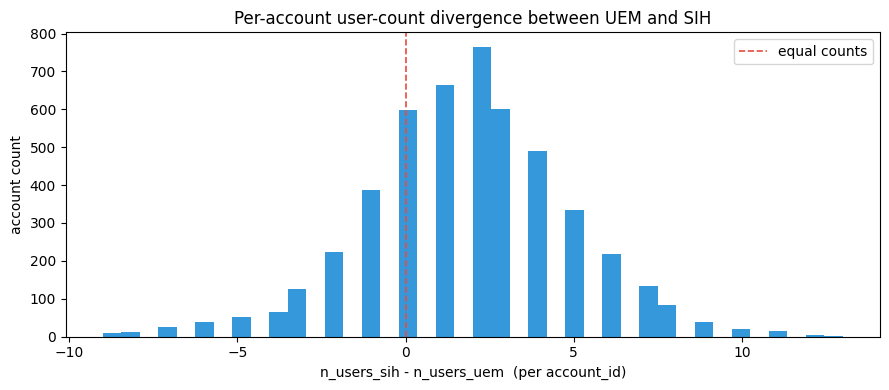

,n_users_uem,n_users_sih,delta
account_id,,,
ACC000000,10,4,-6
ACC000001,2,6,4
ACC000002,5,5,0
ACC000003,2,1,-1
ACC000004,1,2,1
ACC000005,2,3,1
ACC000006,2,2,0
ACC000007,3,7,4
ACC000008,1,4,3


In [22]:
# Testing per-account user-count parity
# For each account_id present in both tables, compare distinct user_id counts.

uem_per_acct = uem_df.groupby('account_id')['user_id'].nunique().rename('n_users_uem')
sih_per_acct = sih_df.groupby('account_id')['user_id'].nunique().rename('n_users_sih')

both = pd.concat([uem_per_acct, sih_per_acct], axis=1, join='inner')
both['delta'] = both['n_users_sih'] - both['n_users_uem']

n_shared = len(both)
n_equal  = (both['delta'] == 0).sum()
n_sih_more = (both['delta'] > 0).sum()
n_uem_more = (both['delta'] < 0).sum()

print(f"Accounts present in both UEM and SIH: {n_shared:,}")
print(f"  equal user counts:        {n_equal:,}  ({n_equal/n_shared*100:.1f}%)")
print(f"  SIH has more users:       {n_sih_more:,}  ({n_sih_more/n_shared*100:.1f}%)")
print(f"  UEM has more users:       {n_uem_more:,}  ({n_uem_more/n_shared*100:.1f}%)")
print(f"\nDelta (sih - uem) summary:")
print(both['delta'].describe().to_string())

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(both['delta'], bins=40, color='#3498db', edgecolor='none')
ax.axvline(0, color='#e74c3c', linestyle='--', linewidth=1.2, label='equal counts')
ax.set_xlabel('n_users_sih - n_users_uem  (per account_id)')
ax.set_ylabel('account count')
ax.set_title('Per-account user-count divergence between UEM and SIH')
ax.legend()
plt.tight_layout()
plt.show()

display(both.head(10))

Accounts in ALE: 5,000
  with >=1 ticket: 4,904
  with 0 tickets:  96  (1.9%) -- potential NaN issue

Overall ticket-count summary:
count    5000.000000
mean        4.477000
std         2.451504
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        15.000000

By account_status (mean / median / n):


,count,mean,median,max
account_status,,,,
active,4454,4.365290,4.0,15
churned,546,5.388278,5.0,14


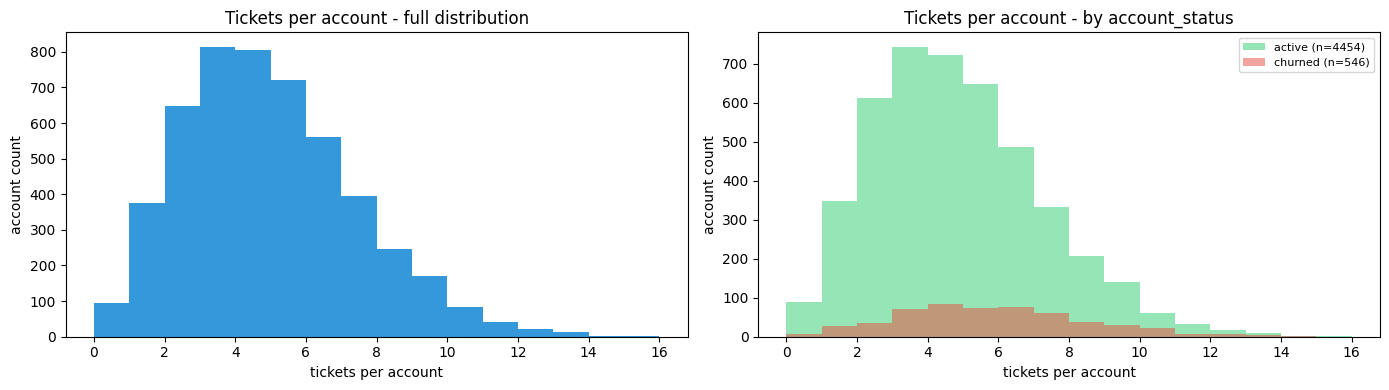

In [23]:
# Testing tickets per account to measure concentration is support volume and the effect of churn

tix_per_acct = sih_df.groupby('account_id').size().rename('n_tickets')
all_accts = ale_df[['account_id', 'account_status']].set_index('account_id')
tix_full = all_accts.join(tix_per_acct).fillna({'n_tickets': 0})
tix_full['n_tickets'] = tix_full['n_tickets'].astype(int)

n_zero = (tix_full['n_tickets'] == 0).sum()
print(f"Accounts in ALE: {len(tix_full):,}")
print(f"  with >=1 ticket: {(tix_full['n_tickets'] > 0).sum():,}")
print(f"  with 0 tickets:  {n_zero:,}  ({n_zero/len(tix_full)*100:.1f}%) -- potential NaN issue")
print(f"\nOverall ticket-count summary:")
print(tix_full['n_tickets'].describe().to_string())

print(f"\nBy account_status (mean / median / n):")
by_status = tix_full.groupby('account_status')['n_tickets'].agg(['count', 'mean', 'median', 'max'])
display(by_status)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(tix_full['n_tickets'], bins=range(0, tix_full['n_tickets'].max() + 2),
             color='#3498db', edgecolor='none')
axes[0].set_xlabel('tickets per account')
axes[0].set_ylabel('account count')
axes[0].set_title('Tickets per account - full distribution')

status_colors = {'active': '#2ecc71', 'churned': '#e74c3c', 'suspended': '#f39c12', 'grace_period': '#9b59b6'}
for status, grp in tix_full.groupby('account_status'):
    axes[1].hist(grp['n_tickets'], bins=range(0, tix_full['n_tickets'].max() + 2),
                 alpha=0.5, label=f'{status} (n={len(grp)})',
                 color=status_colors.get(status, '#95a5a6'), edgecolor='none')
axes[1].set_xlabel('tickets per account')
axes[1].set_ylabel('account count')
axes[1].set_title('Tickets per account - by account_status')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Naive account-level aggregation to build first pass flat table

Aggregation strategies per column informed by business heuristics

**ALE**
Already at the account level

**UEM**
*One account is linked to many users*
- user_id --> num_users
- user_role(member, admin, viewer, billing) --> one hot encoding, sum
- user_status(active, deactivated) --> num_users
- login_count_30d --> sum, average
- login_count_90d --> sum, average
- feature_usage_score --> average, min, max
- sessions_count_30d --> sum, average
- avg_session_duration_minutes --> weighted average with session_count_30d
- reports_generated_30d --> sum, average
- dashboards_created --> sum, average
- dashboards_shared --> sum, average
- exports_count_30d --> sum, average
- api_key_active --> sum, average
- mobile_app_user --> num_mobile_users (all True)
- browser_type --> one_hot_encoding and sum, add spread column
- operating_system --> one_hot_encoding and sum, add spread column
- timezone_offset --> turn into team_geographic_distribution (measures how spread out the teams are based on their timezone)
- language_preference --> one_hot_encoding and sum, add spread column
- notification_preference --> enumerate, sum
- profile_completeness_pct  --> average
- onboarding_completed --> num_onboarding_completed (could correlate highly with num_users)
- certification_earned --> num_certification_earned
- beta_features_enabled --> num_beta_features_enabled
- days_since_last_login --> min (days_since_latest_login), max (days_since_earliest_login)
- days_since_user_creation --> min (days_since_latest_user_creation), max (days_since_earliest_user_creation)

**SIH**
*One account is linked to many tickets*
*The same user can create many tickets within an account*
*Note that not all accounts have tickets, these need to resolve to zeros, not NaN*  
- ticket_id --> num_tickets
- user_id --> num_ticket_creators
- ticket_priority --> enumerate, max, min, average
- ticket_category --> one_hot_encoding, sum, average (leakage risk for 'cancellation_request' maybe could just be a really good signal, consider dropping 100% correlation with cancellation_requested)
- ticket_sentiment --> enumerate, max, min, average
- resolution_time_hours --> max, average, sum
- satisfaction_rating --> num_survey_responses, survey_response_rate, num_low_responses (<2.5), num_high_responses (>2.5)
- escalated --> sum, average
- reopened_count --> sum, max
- cancellation_requested --> sum, average
- cancellation_reason --> num_cancellation_reasons
- retention_offer_made --> sum (could correlate with num_tickets)
- account_pause_requested --> sum (could correlate with num_tickets)
- downgrade_requested --> sum (could correlate with num_tickets)
- competitor_mentioned --> num_competitor_mentions
- agent_id --> num_distinct_agents
- channel --> one_hot_encoding then sum, average
- interaction_count --> sum, average
- iternal_category --> one_hot_encoding, sum (deprecated but could still be used as a signal?)
- sla_breach --> num_sla_breach
- kb_articles_referenced --> sum, average
- days_since_ticket_creation --> min (days_since_latest_ticket_creation), max (days_since_earliest_ticket_creation)
- days_since_resolution --> min (days_since_latest_resolution), max (days_since_earliest_resolution)
- [new] n_tickets_30d (derived, from days_since_ticket_creation)
- [new] n_tickets_90d (derived,from days_since_ticket_creation)

LEAKY_SIH_FIELDS = [`cancellation_requested`, `retention_offer_made`, `downgrade_requested`, `ticket_category` == 'cancellation_reason'ALE_OBVIOUS_DROPS, `account_pause_requested`]

In [24]:
# Aggregating UEM fields to one row per account_id

pd.set_option('display.max_column', None)

g = uem_df.groupby('account_id')

# user counts (overall + by status; 'invited' absent in data)
counts = pd.DataFrame({
    'num_users':             g.size(),
    'num_active_users':      g['user_status'].apply(lambda s: (s == 'active').sum()),
    'num_deactivated_users': g['user_status'].apply(lambda s: (s == 'deactivated').sum()),
})

# user_role one-hot sums (no 'billing' rows in data)
roles = pd.get_dummies(uem_df['user_role']).groupby(uem_df['account_id']).sum()
roles.columns = [f'num_{c}s' for c in roles.columns]

# Activity counters --> per-account sum and average
sums_avgs = {
    'login_count_30d':       ('total_logins_30d',         'avg_logins_30d'),
    'login_count_90d':       ('total_logins_90d',         'avg_logins_90d'),
    'sessions_count_30d':    ('total_sessions_30d',       'avg_sessions_30d'),
    'reports_generated_30d': ('total_reports_30d',        'avg_reports_30d'),
    'dashboards_created':    ('total_dashboards_created', 'avg_dashboards_created'),
    'dashboards_shared':     ('total_dashboards_shared',  'avg_dashboards_shared'),
    'exports_count_30d':     ('total_exports_30d',        'avg_exports_30d'),
}
activity = pd.DataFrame({
    out: (g[src].sum() if out.startswith('total_') else g[src].mean())
    for src, (s_name, a_name) in sums_avgs.items()
    for out in (s_name, a_name)
})

# feature_usage_score --> avg/min/max
fus = g['feature_usage_score'].agg(
    avg_feature_usage_score='mean',
    min_feature_usage_score='min',
    max_feature_usage_score='max',
)

# avg_session_duration_minutes --> weighted by sessions_count_30d (sessions are the natural denominator)
def _weighted_session_duration(grp):
    w, v = grp['sessions_count_30d'], grp['avg_session_duration_minutes']
    tot = w.sum()
    return (v * w).sum() / tot if tot > 0 else np.nan
session_dur = g.apply(_weighted_session_duration).rename('avg_session_duration_minutes')

# Boolean adoption flags --> sum across users in account
bool_sums = pd.DataFrame({
    'num_api_key_active':        g['api_key_active'].sum(),
    'num_mobile_users':          g['mobile_app_user'].sum(),
    'num_onboarding_completed':  g['onboarding_completed'].sum(),
    'num_certification_earned':  g['certification_earned'].sum(),
    'num_beta_features_enabled': g['beta_features_enabled'].sum(),
})

# Categorical spread (nunique is sufficient — class balance across values is even)
spread = pd.DataFrame({
    'n_distinct_browsers':  g['browser_type'].nunique(),
    'n_distinct_os':        g['operating_system'].nunique(),
    'n_distinct_languages': g['language_preference'].nunique(),
})

# Categorical one-hot sums per account (browser / os / language)
browser_oh = pd.get_dummies(uem_df['browser_type'], prefix='num').groupby(uem_df['account_id']).sum()
os_oh      = pd.get_dummies(uem_df['operating_system'], prefix='num').groupby(uem_df['account_id']).sum()
lang_oh    = pd.get_dummies(uem_df['language_preference'], prefix='num_lang').groupby(uem_df['account_id']).sum()

# notification_preference --> ordinal encode then sum / average
notif_ord = uem_df['notification_preference'].map({'none': 0, 'important': 1, 'all': 2})
notif = pd.DataFrame({
    'total_notification_pref': notif_ord.groupby(uem_df['account_id']).sum(),
    'avg_notification_pref':   notif_ord.groupby(uem_df['account_id']).mean(),
})

# timezone_offset --> spread (distinct count + std)
tz = pd.DataFrame({
    'tz_nunique': g['timezone_offset'].nunique(),
    'tz_std':     g['timezone_offset'].std(),
})

# profile_completeness_pct --> account average
profile = g['profile_completeness_pct'].mean().rename('avg_profile_completeness_pct')

# Recency: min = most recent event, max = oldest event in account
recency = pd.DataFrame({
    'days_since_latest_login':           g['days_since_last_login'].min(),
    'days_since_earliest_login':         g['days_since_last_login'].max(),
    'days_since_latest_user_creation':   g['days_since_user_creation'].min(),
    'days_since_earliest_user_creation': g['days_since_user_creation'].max(),
})

uem_agg = pd.concat(
    [counts, roles, activity, fus, session_dur, bool_sums, spread,
     browser_oh, os_oh, lang_oh, notif, tz, profile, recency],
    axis=1,
)
print(f"uem_agg: {uem_agg.shape}")
uem_agg.head(5)

uem_agg: (5000, 54)


,num_users,num_active_users,num_deactivated_users,num_admins,num_members,num_viewers,total_logins_30d,avg_logins_30d,total_logins_90d,avg_logins_90d,total_sessions_30d,avg_sessions_30d,total_reports_30d,avg_reports_30d,total_dashboards_created,avg_dashboards_created,total_dashboards_shared,avg_dashboards_shared,total_exports_30d,avg_exports_30d,avg_feature_usage_score,min_feature_usage_score,max_feature_usage_score,avg_session_duration_minutes,num_api_key_active,num_mobile_users,num_onboarding_completed,num_certification_earned,num_beta_features_enabled,n_distinct_browsers,n_distinct_os,n_distinct_languages,num_chrome,num_edge,num_firefox,num_safari,num_android,num_ios,num_linux,num_macos,num_windows,num_lang_de,num_lang_en,num_lang_es,num_lang_fr,total_notification_pref,avg_notification_pref,tz_nunique,tz_std,avg_profile_completeness_pct,days_since_latest_login,days_since_earliest_login,days_since_latest_user_creation,days_since_earliest_user_creation
account_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ACC000000,10,10,0,1,8,1,169,16.9,481,48.1,140,14.0,94,9.4,43,4.3,13,1.3,64,6.4,85.180028,48.898875,105.948078,38.447794,1,2,10,1,0,4,5,4,2,3,2,3,1,1,2,1,5,3,2,3,2,11,1.1,7,7.846443,79.717720,2,22,797,861
ACC000001,2,2,0,1,1,0,39,19.5,105,52.5,46,23.0,19,9.5,6,3.0,1,0.5,8,4.0,63.675367,44.588427,82.762308,38.580497,0,0,2,1,0,1,1,2,2,0,0,0,0,2,0,0,0,1,0,1,0,1,0.5,2,5.656854,66.742778,2,19,1020,1046
ACC000002,5,5,0,1,3,1,31,6.2,96,19.2,29,5.8,50,10.0,15,3.0,3,0.6,36,7.2,82.221391,66.738654,103.656500,40.902222,0,2,5,1,0,3,4,2,1,0,1,3,2,0,1,1,1,0,0,3,2,6,1.2,4,8.018728,56.160053,3,143,446,506
ACC000003,2,2,0,1,1,0,24,12.0,68,34.0,22,11.0,14,7.0,6,3.0,0,0.0,7,3.5,52.949230,52.792859,53.105601,28.109832,1,1,2,0,1,2,2,1,0,1,1,0,0,1,0,1,0,0,2,0,0,3,1.5,2,9.899495,73.227182,14,16,537,592
ACC000004,1,1,0,1,0,0,0,0.0,0,0.0,0,0.0,11,11.0,6,6.0,2,2.0,12,12.0,111.039446,111.039446,111.039446,NaN,0,1,1,0,0,1,1,1,0,0,1,0,0,1,0,0,0,0,0,1,0,2,2.0,1,NaN,99.503659,134,134,614,614


In [25]:
# Aggregating SIH fields to one row per account_id

pd.set_option('display.max_column', None)

# LEAKY columns: drop these before training a deployable model. Keep computed for baseline comparison.
LEAKY_SIH_FIELDS = [
    'total_cancellation_requested', 'rate_cancellation_requested',
    'num_cancellation', 'rate_cancellation',
    'num_cancellation_reasons',
    'total_retention_offer_made',
    'total_account_pause_requested',
    'total_downgrade_requested',
]

PRIORITY_MAP  = {'low': 0, 'medium': 1, 'high': 2, 'critical': 3}
SENTIMENT_MAP = {'frustrated': 0, 'negative': 1, 'neutral': 2, 'positive': 3}

g = sih_df.groupby('account_id')

# Counts
counts = pd.DataFrame({
    'num_tickets':          g.size(),
    'num_ticket_creators':  g['user_id'].nunique(),
    'num_distinct_agents':  g['agent_id'].nunique(),
})

# ticket_priority / ticket_sentiment --> ordinal encode then min/max/avg
prio_ord = sih_df['ticket_priority'].map(PRIORITY_MAP)
sent_ord = sih_df['ticket_sentiment'].map(SENTIMENT_MAP)
ordinal = pd.DataFrame({
    'max_priority':  prio_ord.groupby(sih_df['account_id']).max(),
    'min_priority':  prio_ord.groupby(sih_df['account_id']).min(),
    'avg_priority':  prio_ord.groupby(sih_df['account_id']).mean(),
    'max_sentiment': sent_ord.groupby(sih_df['account_id']).max(),
    'min_sentiment': sent_ord.groupby(sih_df['account_id']).min(),
    'avg_sentiment': sent_ord.groupby(sih_df['account_id']).mean(),
})

# ticket_category one-hot --> sum (count) and mean (rate)
cat_oh = pd.get_dummies(sih_df['ticket_category']).groupby(sih_df['account_id'])
cat_sums  = cat_oh.sum().add_prefix('num_')
cat_rates = cat_oh.mean().add_prefix('rate_')

# resolution_time_hours --> max / avg / sum
resolution = g['resolution_time_hours'].agg(
    max_resolution_hours='max',
    avg_resolution_hours='mean',
    total_resolution_hours='sum',
)

# satisfaction_rating --> response-rate primary signal (~69% null), plus low/high counts (cutoff 2.5 per plan)
csat = sih_df['satisfaction_rating']
csat_df = pd.DataFrame({
    'num_csat_responses':  csat.notna().groupby(sih_df['account_id']).sum(),
    'csat_response_rate':  csat.notna().groupby(sih_df['account_id']).mean(),
    'num_low_csat':        csat.lt(2.5).groupby(sih_df['account_id']).sum(),
    'num_high_csat':       csat.gt(2.5).groupby(sih_df['account_id']).sum(),
})

# Boolean ticket flags --> sums (and rate where useful)
bools = pd.DataFrame({
    'total_escalated':                g['escalated'].sum(),
    'rate_escalated':                 g['escalated'].mean(),
    'total_sla_breach':               g['sla_breach'].sum(),
    'total_cancellation_requested':   g['cancellation_requested'].sum(),     # LEAKY
    'rate_cancellation_requested':    g['cancellation_requested'].mean(),    # LEAKY
    'total_retention_offer_made':     g['retention_offer_made'].sum(),       # LEAKY
    'total_account_pause_requested':  g['account_pause_requested'].sum(),    # LEAKY
    'total_downgrade_requested':      g['downgrade_requested'].sum(),        # LEAKY
})

# reopened_count --> sum + max
reopened = g['reopened_count'].agg(total_reopened='sum', max_reopened='max')

# Free-text presence --> count of non-null entries per account
text_counts = pd.DataFrame({
    'num_cancellation_reasons':  sih_df['cancellation_reason'].notna().groupby(sih_df['account_id']).sum(),  # LEAKY
    'num_competitor_mentions':   sih_df['competitor_mentioned'].notna().groupby(sih_df['account_id']).sum(),
})

# channel one-hot --> count + rate
ch_oh = pd.get_dummies(sih_df['channel']).groupby(sih_df['account_id'])
ch_sums  = ch_oh.sum().add_prefix('num_')
ch_rates = ch_oh.mean().add_prefix('rate_')

# interaction_count --> total + avg
inter = g['interaction_count'].agg(total_interactions='sum', avg_interactions='mean')

# internal_category (deprecated; 0% null today, but train/serve skew risk if phase-out begins)
ic_null_rate = sih_df['internal_category'].isna().mean()
if ic_null_rate < 0.5:
    ic_oh = pd.get_dummies(sih_df['internal_category'], prefix='num_internal').groupby(sih_df['account_id']).sum()
else:
    print(f"internal_category null rate {ic_null_rate:.1%} — skipping (phase-out underway)")
    ic_oh = pd.DataFrame(index=g.size().index)

# kb_articles_referenced --> total + avg
kb = g['kb_articles_referenced'].agg(total_kb_articles='sum', avg_kb_articles='mean')

# Recency: min = most recent, max = oldest
recency = pd.DataFrame({
    'days_since_latest_ticket_creation':   g['days_since_ticket_creation'].min(),
    'days_since_earliest_ticket_creation': g['days_since_ticket_creation'].max(),
    'days_since_latest_resolution':        g['days_since_resolution'].min(),
    'days_since_earliest_resolution':      g['days_since_resolution'].max(),
})

# Windowed ticket counts derived from days_since_ticket_creation
days = sih_df['days_since_ticket_creation']
windows = pd.DataFrame({
    'n_tickets_30d': days.le(30).groupby(sih_df['account_id']).sum(),
    'n_tickets_90d': days.le(90).groupby(sih_df['account_id']).sum(),
})

sih_agg = pd.concat(
    [counts, ordinal, cat_sums, cat_rates, resolution, csat_df, bools, reopened,
     text_counts, ch_sums, ch_rates, inter, ic_oh, kb, recency, windows],
    axis=1,
)
print(f"sih_agg: {sih_agg.shape}")
print(f"LEAKY_SIH_FIELDS ({len(LEAKY_SIH_FIELDS)}): {LEAKY_SIH_FIELDS}")
sih_agg.head(5)

sih_agg: (4904, 59)
LEAKY_SIH_FIELDS (8): ['total_cancellation_requested', 'rate_cancellation_requested', 'num_cancellation', 'rate_cancellation', 'num_cancellation_reasons', 'total_retention_offer_made', 'total_account_pause_requested', 'total_downgrade_requested']


,num_tickets,num_ticket_creators,num_distinct_agents,max_priority,min_priority,avg_priority,max_sentiment,min_sentiment,avg_sentiment,num_billing,num_bug,num_cancellation,num_feature_request,num_technical,rate_billing,rate_bug,rate_cancellation,rate_feature_request,rate_technical,max_resolution_hours,avg_resolution_hours,total_resolution_hours,num_csat_responses,csat_response_rate,num_low_csat,num_high_csat,total_escalated,rate_escalated,total_sla_breach,total_cancellation_requested,rate_cancellation_requested,total_retention_offer_made,total_account_pause_requested,total_downgrade_requested,total_reopened,max_reopened,num_cancellation_reasons,num_competitor_mentions,num_chat,num_email,num_phone,num_self_service,rate_chat,rate_email,rate_phone,rate_self_service,total_interactions,avg_interactions,num_internal_cat_a,num_internal_cat_b,num_internal_cat_c,total_kb_articles,avg_kb_articles,days_since_latest_ticket_creation,days_since_earliest_ticket_creation,days_since_latest_resolution,days_since_earliest_resolution,n_tickets_30d,n_tickets_90d
account_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ACC000000,4,4,4,2,2,2.0,2,1,1.500000,1,2,0,0,1,0.250000,0.500000,0.0,0.0,0.250000,41.839001,32.458673,129.834693,1,0.250000,1,0,2,0.500000,4,0,0.0,0,0,0,4,2,0,0,1,1,0,2,0.25,0.250000,0.000000,0.500000,16,4.000000,1,2,1,11,2.75,342,854,340,852,0,0
ACC000001,7,6,6,2,0,1.0,2,1,1.428571,2,3,0,0,2,0.285714,0.428571,0.0,0.0,0.285714,64.521854,37.492658,262.448607,3,0.428571,3,0,2,0.285714,7,0,0.0,0,0,0,7,4,0,0,0,2,4,1,0.00,0.285714,0.571429,0.142857,36,5.142857,2,2,3,7,1.00,243,1004,241,1002,0,0
ACC000002,5,5,5,3,2,2.2,2,1,1.400000,1,1,0,2,1,0.200000,0.200000,0.0,0.4,0.200000,37.822025,32.986979,164.934896,0,0.000000,0,0,2,0.400000,5,0,0.0,0,0,0,7,4,0,0,0,2,1,2,0.00,0.400000,0.200000,0.400000,21,4.200000,2,2,1,5,1.00,188,527,186,525,0,0
ACC000003,1,1,1,1,1,1.0,3,3,3.000000,0,0,0,1,0,0.000000,0.000000,0.0,1.0,0.000000,20.129521,20.129521,20.129521,1,1.000000,0,1,0,0.000000,0,0,0.0,0,0,0,0,0,0,0,0,1,0,0,0.00,1.000000,0.000000,0.000000,4,4.000000,0,0,1,0,0.00,419,419,418,418,0,0
ACC000004,2,2,2,1,1,1.0,2,2,2.000000,0,1,0,0,1,0.000000,0.500000,0.0,0.0,0.500000,25.121786,22.622851,45.245702,0,0.000000,0,0,0,0.000000,1,0,0.0,0,0,0,2,2,0,0,2,0,0,0,1.00,0.000000,0.000000,0.000000,11,5.500000,1,1,0,0,0.00,226,626,224,625,0,0


In [26]:
# Append aggregated columns to ALE dataframe (left-merge on account_id)

ale_df = ale_df.merge(uem_agg, how='left', on='account_id').merge(sih_agg, how='left', on='account_id')

# Accounts with 0 tickets (~33% per cell 30) get NaN from the SIH merge for count/sum/rate columns;
# those should resolve to 0. Recency columns stay NaN — "no ticket" != "ticket 0 days ago".
sih_recency_cols = [
    'days_since_latest_ticket_creation', 'days_since_earliest_ticket_creation',
    'days_since_latest_resolution', 'days_since_earliest_resolution',
]
sih_zero_fill = [c for c in sih_agg.columns if c not in sih_recency_cols]
ale_df[sih_zero_fill] = ale_df[sih_zero_fill].fillna(0)

# UEM aggregates that are mathematically undefined for some accounts (collapse to 0)
# avg_session_duration_minutes: NaN when all users had 0 sessions --> 0 minutes
# tz_std: NaN for single-user accounts --> 0 spread (single-user signal preserved in num_users)
ale_df[['avg_session_duration_minutes', 'tz_std']] = ale_df[['avg_session_duration_minutes', 'tz_std']].fillna(0)

# Sanity checks
assert ale_df['account_id'].is_unique, "row inflation from merge"
print(f"ale_df shape: {ale_df.shape}")
print(f"NaNs in SIH count/rate/sum cols (expect 0): {ale_df[sih_zero_fill].isna().sum().sum()}")
print(f"NaN rate in ticket recency cols (expect ~2%):")
print((ale_df[sih_recency_cols].isna().mean() * 100).round(1).to_string())
ale_df.head(5)

ale_df shape: (5000, 141)
NaNs in SIH count/rate/sum cols (expect 0): 0
NaN rate in ticket recency cols (expect ~2%):
days_since_latest_ticket_creation      1.9
days_since_earliest_ticket_creation    1.9
days_since_latest_resolution           1.9
days_since_earliest_resolution         1.9


,account_id,org_id,created_timestamp,last_activity_timestamp,account_status,status_change_date,subscription_tier,mrr,billing_cycle,payment_method,auto_renew_enabled,seats_purchased,seats_active,contract_end_date,account_health_score,risk_flag,region,account_manager_id,integration_count,api_calls_enabled,sso_enabled,white_label_enabled,provisioning_method,internal_notes_count,days_since_creation,days_since_last_activity,days_since_contract_end,days_since_status_change,num_users,num_active_users,num_deactivated_users,num_admins,num_members,num_viewers,total_logins_30d,avg_logins_30d,total_logins_90d,avg_logins_90d,total_sessions_30d,avg_sessions_30d,total_reports_30d,avg_reports_30d,total_dashboards_created,avg_dashboards_created,total_dashboards_shared,avg_dashboards_shared,total_exports_30d,avg_exports_30d,avg_feature_usage_score,min_feature_usage_score,max_feature_usage_score,avg_session_duration_minutes,num_api_key_active,num_mobile_users,num_onboarding_completed,num_certification_earned,num_beta_features_enabled,n_distinct_browsers,n_distinct_os,n_distinct_languages,num_chrome,num_edge,num_firefox,num_safari,num_android,num_ios,num_linux,num_macos,num_windows,num_lang_de,num_lang_en,num_lang_es,num_lang_fr,total_notification_pref,avg_notification_pref,tz_nunique,tz_std,avg_profile_completeness_pct,days_since_latest_login,days_since_earliest_login,days_since_latest_user_creation,days_since_earliest_user_creation,num_tickets,num_ticket_creators,num_distinct_agents,max_priority,min_priority,avg_priority,max_sentiment,min_sentiment,avg_sentiment,num_billing,num_bug,num_cancellation,num_feature_request,num_technical,rate_billing,rate_bug,rate_cancellation,rate_feature_request,rate_technical,max_resolution_hours,avg_resolution_hours,total_resolution_hours,num_csat_responses,csat_response_rate,num_low_csat,num_high_csat,total_escalated,rate_escalated,total_sla_breach,total_cancellation_requested,rate_cancellation_requested,total_retention_offer_made,total_account_pause_requested,total_downgrade_requested,total_reopened,max_reopened,num_cancellation_reasons,num_competitor_mentions,num_chat,num_email,num_phone,num_self_service,rate_chat,rate_email,rate_phone,rate_self_service,total_interactions,avg_interactions,num_internal_cat_a,num_internal_cat_b,num_internal_cat_c,total_kb_articles,avg_kb_articles,days_since_latest_ticket_creation,days_since_earliest_ticket_creation,days_since_latest_resolution,days_since_earliest_resolution,n_tickets_30d,n_tickets_90d
0,ACC000000,ORG00697,2022-08-17,2024-12-21,active,2023-12-17,professional,182.372000,annual,credit_card,True,35,8,2024-08-16,94.849799,False,EU,AM34,4,True,False,True,sales_led,0,869,12,139,382,10,10,0,1,8,1,169,16.9,481,48.1,140,14.0,94,9.4,43,4.3,13,1.3,64,6.4,85.180028,48.898875,105.948078,38.447794,1,2,10,1,0,4,5,4,2,3,2,3,1,1,2,1,5,3,2,3,2,11,1.1,7,7.846443,79.717720,2,22,797,861,4.0,4.0,4.0,2.0,2.0,2.0,2.0,1.0,1.500000,1.0,2.0,0.0,0.0,1.0,0.250000,0.500000,0.0,0.0,0.250000,41.839001,32.458673,129.834693,1.0,0.250000,1.0,0.0,2.0,0.500000,4.0,0.0,0.0,0.0,0.0,0.0,4.0,2.0,0.0,0.0,1.0,1.0,0.0,2.0,0.25,0.250000,0.000000,0.500000,16.0,4.000000,1.0,2.0,1.0,11.0,2.75,342.0,854.0,340.0,852.0,0.0,0.0
1,ACC000001,ORG00246,2022-02-21,2024-12-22,active,2023-01-02,professional,200.941898,monthly,invoice,True,33,9,2024-02-21,86.324272,False,LATAM,AM34,3,False,False,False,self_serve,0,1046,11,316,731,2,2,0,1,1,0,39,19.5,105,52.5,46,23.0,19,9.5,6,3.0,1,0.5,8,4.0,63.675367,44.588427,82.762308,38.580497,0,0,2,1,0,1,1,2,2,0,0,0,0,2,0,0,0,1,0,1,0,1,0.5,2,5.656854,66.742778,2,19,1020,1046,7.0,6.0,6.0,2.0,0.0,1.0,2.0,1.0,1.428571,2.0,3.0,0.0,0.0,2.0,0.285714,0.428571,0.0,0.0,0.285714,64.521854,37.492658,262.448607,3.0,0.428571,3.0,0.0,2.0,0.285714,7.0,0.0,0.0,0.0,0.0,0.0,7.0,4.0,0.0,0.0,0.0,2.0,4.0,1.0,0.00,0.285714,0.571429,0.142857,36.0,5.142857,2.0,2.0,3.0,7.0,1.00,243.0,1004.0,241.0,1002.0,0.0,0.0
2,ACC000002,ORG01163,2023-07-18,2024-12-10,active,2024-07-29,professional,195.391229,monthly,credit

In [27]:
# Final ALE preprocessing — drops, encodings, target binarization

# 1. ID + leakage + datetime drops
ALE_DROPS = [
    'account_id', 'org_id', 'account_manager_id',          # identifiers
    'days_since_status_change',                             # leakage: 21% forward-looking
    'created_timestamp', 'last_activity_timestamp',         # datetime sources (durations already derived)
    'status_change_date', 'contract_end_date',
]
ale_df.drop(columns=ALE_DROPS, inplace=True)

# 2. Target: churned vs not
ale_df['account_status'] = (ale_df['account_status'] == 'churned').astype(int)

# 3. subscription_tier --> ordinal
TIER_MAP = {'free': 1, 'starter': 2, 'professional': 3, 'enterprise': 4}
ale_df['subscription_tier'] = ale_df['subscription_tier'].map(TIER_MAP)

# 4. account_health_score --> band (50 = middle of dead-band, see cell 22)
ale_df['health_score_band'] = (ale_df['account_health_score'] >= 50).astype(int)
ale_df.drop(columns=['account_health_score'], inplace=True)

# 5. Nominal categoricals --> one-hot
for col in ['region', 'billing_cycle', 'payment_method', 'provisioning_method']:
    oh = pd.get_dummies(ale_df[col], prefix=col).astype(int)
    ale_df.drop(columns=[col], inplace=True)
    ale_df = pd.concat([ale_df, oh], axis=1)

# 6. Booleans --> int
BOOL_COLS = ['auto_renew_enabled', 'risk_flag',
             'api_calls_enabled', 'sso_enabled', 'white_label_enabled']
ale_df[BOOL_COLS] = ale_df[BOOL_COLS].astype(int)

# Sanity: no object/datetime dtypes remain
non_numeric = ale_df.select_dtypes(exclude='number').columns.tolist()
assert not non_numeric, f"non-numeric cols remain: {non_numeric}"
print(f"ale_df shape: {ale_df.shape}")
print(f"churn rate: {ale_df['account_status'].mean():.1%}")
print(f"dtypes: {ale_df.dtypes.value_counts().to_dict()}")

ale_df shape: (5000, 142)
churn rate: 10.9%
dtypes: {dtype('float64'): 74, dtype('int64'): 68}


In [33]:
# Saving preprocessed df as a new object

# pp_df = ale_df.copy()

# Save to a new csv to produce sweetviz
# pp_df.to_csv('../data/preprocessed/pp_report.csv', index=False)

# import sweetviz as sv

# pp_report = sv.analyze(pp_df)

# pp_report.show_html("../data/profiles/pp_report.html", open_browser=False)

/Users/vidyutveedgav/churnguard-analytics/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[Step 3/3] Generating associations graph     |          | [  0%]   00:00 -> (? left)    /Users/vidyutveedgav/churnguard-analytics/.venv/lib/python3.13/site-packages/sweetviz/graph_associations.py:219: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_dataframe[feature] = pd.Series(dtype=float)
/Users/vidyutveedgav/churnguard-analytics/.venv/lib/python3.13/site-packages/sweetviz/graph_associations.py:219: PerformanceWarning: DataFrame is highly fragmented.  This is usually the resu

Report ../data/profiles/pp_report.html was generated.


## Feature selection

**Experiments**
1. Univariate correlation with 